Mounted at /content/drive
CREATING WEEK-2 PACKAGE

Baseline results loaded.
Number of evaluated samples: 48

Metric comparison:


PSNR                             SSIM                          \
              mean     std     min      max    mean     std     min     max   
method                                                                        
CLAHE      13.8881  4.5284  7.1895  24.8260  0.6136  0.2594  0.2080  0.9597   
Gamma      13.8936  5.2338  6.5382  25.2294  0.6546  0.2628  0.2346  0.9809   
GrayWorld  13.3272  3.9522  7.5538  24.8763  0.6539  0.2477  0.2541  0.9790   

          Edge_Preservation                       
                       mean     std  min     max  
method                                            
CLAHE                0.0250  0.0295  0.0  0.1287  
Gamma                0.0067  0.0146  0.0  0.0683  
GrayWorld            0.0082  0.0194  0.0  0.1025

,method,PSNR,SSIM,Edge_Preservation
0,CLAHE,13.8881,0.6136,0.0250
1,Gamma,13.8936,0.6546,0.0067
2,GrayWorld,13.3272,0.6539,0.0082



Highest mean value for each metric:


,Metric,Highest_Mean_Method
0,PSNR,Gamma
1,SSIM,Gamma
2,Edge Preservation,CLAHE


...

,Method,Potential_Artifacts,Expected_Difficult_Scenes,What_To_Inspect
0,CLAHE,"Over-enhancement of local contrast, amplificat...","Low-contrast scenes, noisy regions, highly tex...","Noise amplification, halos, excessive local co..."
1,Gamma,Over-brightening or unnatural illumination whe...,Very dark scenes or scenes with uneven illumin...,"Loss of natural brightness, washed-out regions"
2,Gray-World,Possible color imbalance when the Gray-World a...,Strong underwater color casts or scenes with n...,Unnatural colors or excessive channel correction



Peer insight file created:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Week_2_Package/peer_insights.csv


,Peer,Observation,Method_or_Scene,Suggested_Change,Action_Taken
0,,,,,



Hypotheses:


,Hypothesis_ID,Hypothesis,Evidence_To_Check,Status
0,H1,Low-contrast underwater scenes may benefit mor...,Compare CLAHE performance on low-contrast samp...,To investigate
1,H2,Strong illumination differences may make simpl...,Inspect gamma results across dark and normally...,To investigate
2,H3,Strong color casts may affect the effectivenes...,Compare Gray-World outputs in scenes with diff...,To investigate
3,H4,Noise and low visibility may reduce the qualit...,Inspect difficult samples and their edge maps.,To investigate
4,H5,Preserving structural edges is important for p...,Compare edge-preservation scores and visual ed...,To investigate


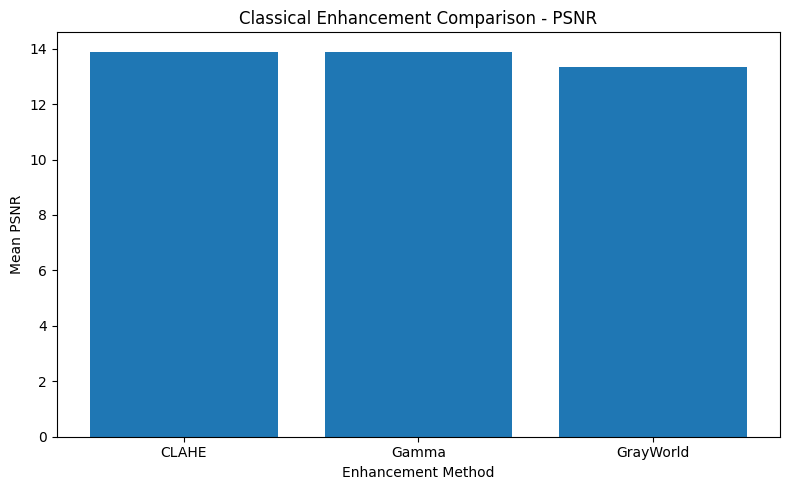

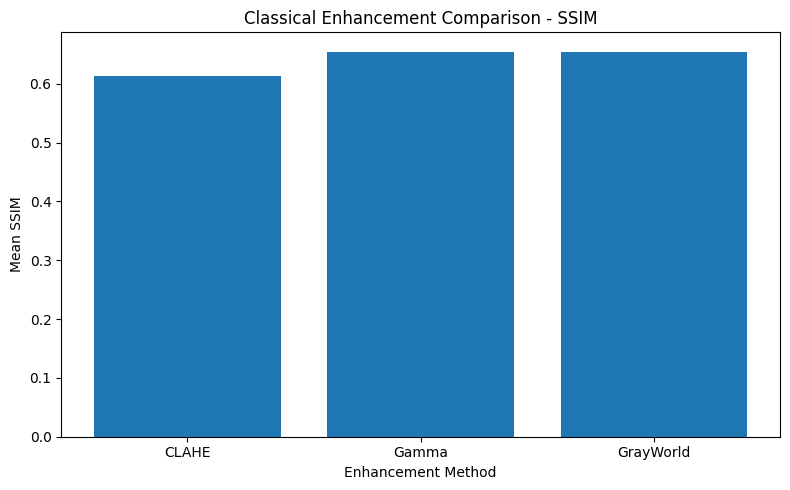

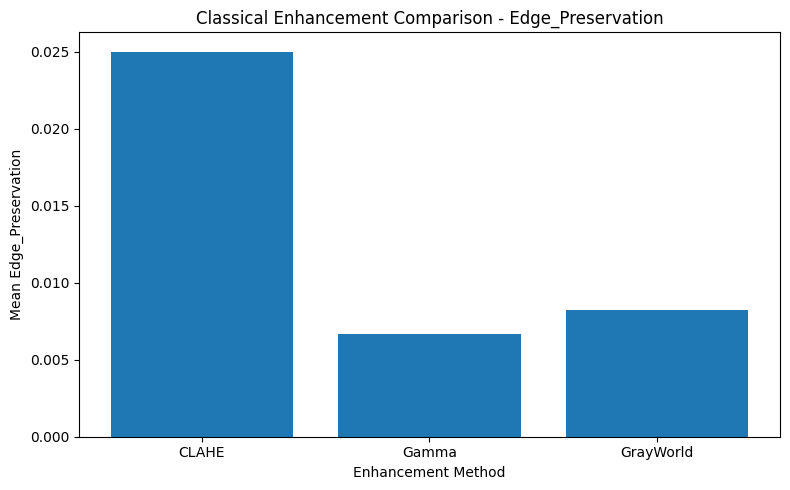



WEEK-2 PACKAGE COMPLETE

Saved in:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Week_2_Package

Files:
 - Edge_Preservation_comparison.png
 - PSNR_comparison.png
 - SSIM_comparison.png
 - Week_2_Report.txt
 - Week_2_summary.json
 - artifact_analysis.csv
 - baseline_metric_comparison.csv
 - baseline_metric_comparison_detailed.csv
 - difficult_samples.csv
 - hypotheses.csv
 - metric_best_methods.csv
 - peer_insights.csv
 - representative_difficult_cases.csv


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Underwater-Image-Data-set-main"
)

V1_DIR = PROJECT_DIR / "Dataset_V1"

BASELINE_DIR = V1_DIR / "Classical_Baselines"

WEEK2_DIR = PROJECT_DIR / "Week_2_Package"

WEEK2_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("CREATING WEEK-2 PACKAGE")
print("=" * 70)

results_file = (
    BASELINE_DIR /
    "all_baseline_results.csv"
)

comparison_file = (
    BASELINE_DIR /
    "baseline_comparison.csv"
)

if not results_file.exists():
    raise FileNotFoundError(
        "all_baseline_results.csv was not found. "
        "Run the classical baseline cell first."
    )

results_df = pd.read_csv(
    results_file
)

comparison_df = pd.read_csv(
    comparison_file
)

print("\nBaseline results loaded.")
print(
    "Number of evaluated samples:",
    results_df["sample_id"].nunique()
)

metric_columns = [
    "PSNR",
    "SSIM",
    "Edge_Preservation"
]

metric_summary = (
    results_df
    .groupby("method")[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

metric_summary.to_csv(
    WEEK2_DIR /
    "baseline_metric_comparison_detailed.csv"
)

print("\nMetric comparison:")
display(metric_summary)

simple_comparison = (
    results_df
    .groupby("method")[metric_columns]
    .mean()
    .reset_index()
    .round(4)
)

simple_comparison.to_csv(
    WEEK2_DIR /
    "baseline_metric_comparison.csv",
    index=False
)

display(simple_comparison)

best_psnr = simple_comparison.loc[
    simple_comparison["PSNR"].idxmax(),
    "method"
]

best_ssim = simple_comparison.loc[
    simple_comparison["SSIM"].idxmax(),
    "method"
]

best_edge = simple_comparison.loc[
    simple_comparison["Edge_Preservation"].idxmax(),
    "method"
]

metric_winners = pd.DataFrame({
    "Metric": [
        "PSNR",
        "SSIM",
        "Edge Preservation"
    ],
    "Highest_Mean_Method": [
        best_psnr,
        best_ssim,
        best_edge
    ]
})

metric_winners.to_csv(
    WEEK2_DIR /
    "metric_best_methods.csv",
    index=False
)

print("\nHighest mean value for each metric:")
display(metric_winners)

sample_analysis = (
    results_df
    .groupby("sample_id")[metric_columns]
    .mean()
    .reset_index()
)

for metric in metric_columns:

    minimum = sample_analysis[metric].min()
    maximum = sample_analysis[metric].max()

    if maximum > minimum:
        sample_analysis[
            metric + "_Normalized"
        ] = (
            sample_analysis[metric] - minimum
        ) / (
            maximum - minimum
        )

    else:
        sample_analysis[
            metric + "_Normalized"
        ] = 0.5

sample_analysis["Difficulty_Score"] = 1 - (
    sample_analysis[
        [
            "PSNR_Normalized",
            "SSIM_Normalized",
            "Edge_Preservation_Normalized"
        ]
    ].mean(axis=1)
)

difficult_samples = (
    sample_analysis
    .sort_values(
        "Difficulty_Score",
        ascending=False
    )
    .head(15)
)

difficult_samples.to_csv(
    WEEK2_DIR /
    "difficult_samples.csv",
    index=False
)

print("\nTop difficult samples:")
display(difficult_samples)

artifact_analysis = pd.DataFrame({

    "Method": [
        "CLAHE",
        "Gamma",
        "Gray-World"
    ],

    "Potential_Artifacts": [
        "Over-enhancement of local contrast, amplification of noise or texture",
        "Over-brightening or unnatural illumination when gamma adjustment is strong",
        "Possible color imbalance when the Gray-World assumption does not hold"
    ],

    "Expected_Difficult_Scenes": [
        "Low-contrast scenes, noisy regions, highly textured regions",
        "Very dark scenes or scenes with uneven illumination",
        "Strong underwater color casts or scenes with non-neutral dominant colors"
    ],

    "What_To_Inspect": [
        "Noise amplification, halos, excessive local contrast",
        "Loss of natural brightness, washed-out regions",
        "Unnatural colors or excessive channel correction"
    ]
})

artifact_analysis.to_csv(
    WEEK2_DIR /
    "artifact_analysis.csv",
    index=False
)

print("\nArtifact analysis:")
display(artifact_analysis)

hard_ids = (
    results_df
    .groupby("sample_id")["SSIM"]
    .mean()
    .sort_values()
    .head(5)
    .index
    .tolist()
)

hard_cases = results_df[
    results_df["sample_id"].isin(hard_ids)
].copy()

hard_cases.to_csv(
    WEEK2_DIR /
    "representative_difficult_cases.csv",
    index=False
)

peer_file = (
    WEEK2_DIR /
    "peer_insights.csv"
)

if peer_file.exists():

    peer_df = pd.read_csv(
        peer_file
    )

else:

    peer_df = pd.DataFrame({
        "Peer": [""],
        "Observation": [""],
        "Method_or_Scene": [""],
        "Suggested_Change": [""],
        "Action_Taken": [""]
    })

    peer_df.to_csv(
        peer_file,
        index=False
    )

print("\nPeer insight file created:")
print(peer_file)

display(peer_df)

hypotheses = pd.DataFrame({

    "Hypothesis_ID": [
        "H1",
        "H2",
        "H3",
        "H4",
        "H5"
    ],

    "Hypothesis": [
        "Low-contrast underwater scenes may benefit more from local contrast enhancement such as CLAHE.",
        "Strong illumination differences may make simple gamma correction less consistent across scenes.",
        "Strong color casts may affect the effectiveness of Gray-World white balancing.",
        "Noise and low visibility may reduce the quality of both enhancement and edge preservation.",
        "Preserving structural edges is important for producing visually faithful underwater enhancement."
    ],

    "Evidence_To_Check": [
        "Compare CLAHE performance on low-contrast samples.",
        "Inspect gamma results across dark and normally illuminated samples.",
        "Compare Gray-World outputs in scenes with different color casts.",
        "Inspect difficult samples and their edge maps.",
        "Compare edge-preservation scores and visual edge maps."
    ],

    "Status": [
        "To investigate",
        "To investigate",
        "To investigate",
        "To investigate",
        "To investigate"
    ]
})

hypotheses.to_csv(
    WEEK2_DIR /
    "hypotheses.csv",
    index=False
)

print("\nHypotheses:")
display(hypotheses)

for metric in metric_columns:

    plt.figure(figsize=(8, 5))

    plt.bar(
        simple_comparison["method"],
        simple_comparison[metric]
    )

    plt.xlabel(
        "Enhancement Method"
    )

    plt.ylabel(
        f"Mean {metric}"
    )

    plt.title(
        f"Classical Enhancement Comparison - {metric}"
    )

    plt.tight_layout()

    plt.savefig(
        WEEK2_DIR /
        f"{metric}_comparison.png",
        dpi=300
    )

    plt.show()

selected_reference_file = (
    BASELINE_DIR /
    "Dataset_V1_classical_baseline_report.json"
)

selected_reference = "Not determined"

if selected_reference_file.exists():

    with open(
        selected_reference_file,
        "r"
    ) as f:

        baseline_report = json.load(f)

    selected_reference = baseline_report.get(
        "selected_reference",
        "Not determined"
    )

summary = {
    "Week": "Week 2",
    "Dataset": "Dataset V1",
    "Evaluation": "Classical enhancement baselines",
    "Methods": [
        "CLAHE",
        "Gamma Correction",
        "Gray-World White Balance"
    ],
    "Metrics": [
        "PSNR",
        "SSIM",
        "Edge Preservation"
    ],
    "Selected_Classical_Reference":
        selected_reference,
    "Difficult_Samples_Identified":
        len(difficult_samples),
    "Artifacts_Reviewed": [
        "Contrast over-enhancement",
        "Noise amplification",
        "Brightness/illumination changes",
        "Color imbalance",
        "Edge/texture changes"
    ],
    "Peer_Insight_Status":
        "Template created; add actual peer feedback",
    "Hypothesis_Status":
        "Initial hypotheses documented",
    "Next_Step":
        "Use the classical reference as a benchmark for evaluating the learning-based enhancement model."
}

with open(
    WEEK2_DIR /
    "Week_2_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

report_lines = []

report_lines.append(
    "WEEK-2 CLASSICAL ENHANCEMENT PACKAGE"
)

report_lines.append(
    "=" * 60
)

report_lines.append("")

report_lines.append(
    "1. METHODS EVALUATED"
)

report_lines.append(
    "CLAHE, Gamma Correction, Gray-World White Balance"
)

report_lines.append("")

report_lines.append(
    "2. IMAGE-QUALITY METRICS"
)

report_lines.append(
    "PSNR, SSIM and Edge Preservation"
)

report_lines.append("")

report_lines.append(
    "3. BASELINE COMPARISON"
)

report_lines.append(
    simple_comparison.to_string(
        index=False
    )
)

report_lines.append("")

report_lines.append(
    "4. METRIC-SPECIFIC HIGHEST MEAN VALUES"
)

report_lines.append(
    metric_winners.to_string(
        index=False
    )
)

report_lines.append("")

report_lines.append(
    "5. SELECTED CLASSICAL REFERENCE"
)

report_lines.append(
    str(selected_reference)
)

report_lines.append("")

report_lines.append(
    "6. ARTIFACTS TO REVIEW"
)

for row in artifact_analysis.itertuples():

    report_lines.append(
        f"- {row.Method}: "
        f"{row.Potential_Artifacts}"
    )

report_lines.append("")

report_lines.append(
    "7. DIFFICULT SCENES"
)

report_lines.append(
    "Representative difficult samples were identified "
    "using low metric performance."
)

report_lines.append(
    f"Number saved for inspection: "
    f"{len(difficult_samples)}"
)

report_lines.append("")

report_lines.append(
    "8. PEER INSIGHT"
)

report_lines.append(
    "Peer insight template created. "
    "Actual peer observations should be entered after review."
)

report_lines.append("")

report_lines.append(
    "9. HYPOTHESES"
)

for row in hypotheses.itertuples():

    report_lines.append(
        f"{row.Hypothesis_ID}: "
        f"{row.Hypothesis}"
    )

report_lines.append("")

report_lines.append(
    "10. NEXT STEP"
)

report_lines.append(
    "Use the selected classical enhancement method "
    "as the reference baseline for the learning-based model."
)

report_file = (
    WEEK2_DIR /
    "Week_2_Report.txt"
)

with open(
    report_file,
    "w"
) as f:

    f.write(
        "\n".join(report_lines)
    )

print("\n")
print("=" * 70)
print("WEEK-2 PACKAGE COMPLETE")
print("=" * 70)

print("\nSaved in:")
print(WEEK2_DIR)

print("\nFiles:")

for file in sorted(
    WEEK2_DIR.iterdir()
):

    if file.is_file():
        print(" -", file.name)